In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
import pandas as pd

In [25]:
metadata= pd.read_csv('data/combined_metadata.csv')
y= metadata[['geo_accession','metastasis_status','time']].set_index('geo_accession')
X = pd.read_csv('data/combined_expression_data_scaled.csv', index_col=0).convert_dtypes().transpose()

In [45]:
def fit_and_score_features2(X):
   y=X[["event_observed","duration"]]
   X.drop(["duration", "event_observed"], axis=1, inplace=True)
   n_features = X.shape[1]
   scores = np.empty(n_features)
   m = CoxPHFitter()

   for j in range(n_features):
       Xj = X.iloc[:, j:j+1]
       Xj=pd.merge(Xj, y,  how='right', left_index=True, right_index=True)
       m.fit(Xj, duration_col="duration", event_col="event_observed", show_progress=True)
       scores[j] = m.score_
   return scores

def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = []
    # Fit a CoxPH model for each feature
    for j in range(n_features):
        Xj = X.iloc[:, j : j + 1] # Select one feature

        try:
            Xj = pd.merge(Xj, y, left_index=True, right_index=True)
            #Xj= Xj['1007_s_at'].drop_duplicates()
            m = CoxPHFitter()
            m.fit(Xj, 'time','metastasis_status' )
            scores.append(m.summary)
        except Exception as e:
            scores[j] = 0.0
    return scores

scores = fit_and_score_features(X, y)

In [49]:
df=pd.concat(scores, ignore_index=True)

In [52]:
df.index = X.columns
df.head()

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
ID_REF,,,,,,,,,,,
1007_s_at,0.052406,1.053804,0.169497,-0.279801,0.384614,0.755934,1.469047,0.0,0.309189,7.571780e-01,0.401296
1053_at,1.127196,3.086987,0.201514,0.732235,1.522156,2.079724,4.582094,0.0,5.593633,2.223668e-08,25.422483
117_at,0.120392,1.127939,0.092257,-0.060429,0.301213,0.941361,1.351498,0.0,1.304959,1.919067e-01,2.381523
121_at,-0.257783,0.772763,0.212171,-0.673630,0.158064,0.509854,1.171241,0.0,-1.214981,2.243733e-01,2.156027
1255_g_at,0.468415,1.597460,0.144028,0.186124,0.750706,1.204572,2.118494,0.0,3.252239,1.144996e-03,9.770441


In [53]:
df.to_csv('lifeline_univ_cox_pvals.csv')

(array([4810., 1340.,  981.,  828.,  682.,  633.,  573.,  617.,  558.,
         468.,  502.,  484.,  446.,  462.,  415.,  445.,  397.,  360.,
         332.,  334.,  346.,  374.,  390.,  360.,  314.,  346.,  327.,
         334.,  312.,  321.,  295.,  331.,  284.,  332.,  311.,  325.,
         285.,  337.,  316.,  308.]),
 array([1.21296742e-10, 2.50000001e-02, 5.00000001e-02, 7.50000001e-02,
        1.00000000e-01, 1.25000000e-01, 1.50000000e-01, 1.75000000e-01,
        2.00000000e-01, 2.25000000e-01, 2.50000000e-01, 2.75000000e-01,
        3.00000000e-01, 3.25000000e-01, 3.50000000e-01, 3.75000000e-01,
        4.00000000e-01, 4.25000000e-01, 4.50000000e-01, 4.75000000e-01,
        5.00000000e-01, 5.25000000e-01, 5.50000000e-01, 5.75000000e-01,
        6.00000000e-01, 6.25000000e-01, 6.50000000e-01, 6.75000000e-01,
        7.00000000e-01, 7.25000000e-01, 7.50000000e-01, 7.75000000e-01,
        8.00000000e-01, 8.25000000e-01, 8.50000000e-01, 8.75000000e-01,
        9.00000000e-01, 9.2500

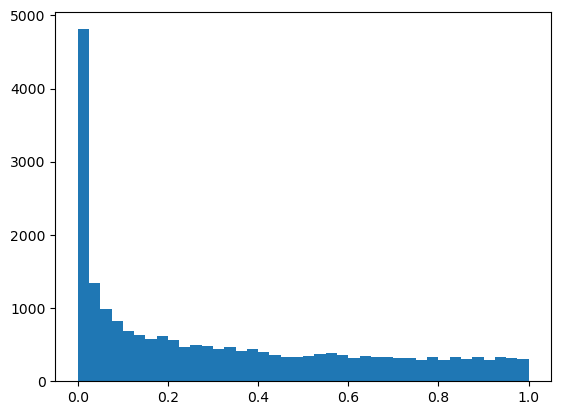

In [55]:
plt.hist(df.p, bins=40)

In [57]:
sig = df[df.p<=0.05].shape[0]
print("precent sig", sig / len(df))

precent sig 0.27683997299122215


In [65]:
sig

6150

In [64]:
sig_ids = df[df.p<=0.05].index.to_list()
sig_expression = X.loc[:,sig_ids]
sig_expression.to_csv('./data/lifeline_univ_cox_sig_expression.csv')